# DeepGlobe 2018 Road Extraction with TorchGeo

## Goal
The primary goal of this workflow is to perform **Semantic Segmentation** to extract road networks from satellite imagery. By training a deep learning model, we aim to automatically classify every pixel in an input satellite image as either "road" or "background."

## Dataset Context
This workflow uses the **DeepGlobe 2018 Road Extraction Challenge** dataset. 
* **Challenge:** Roads are crucial for disaster response, urban planning, and navigation. This dataset captures roads in various terrains (urban, rural, desert, etc.).
* **Data Split:** In this specific implementation, we utilize the collected **train set** of the challenge. To ensure robust evaluation, we perform a custom split of this data into **Train (60%)**, **Validation (20%)**, and **Test (20%)** sets.

## Citation
Demir, I., Koperski, K., Lindenbaum, D., Pang, G., Huang, J., Basu, S., Hughes, F., Tuia, D., & Raskar, R. (2018). DeepGlobe 2018: A Challenge to Parse the Earth through Satellite Images. The IEEE Conference on Computer Vision and Pattern Recognition (CVPR) Workshops, 172–17209. https://doi.org/10.1109/cvprw.2018.00031

## 1. Setup and Imports

First, we import the necessary libraries. 
* **TorchGeo** is the core library used here, providing geospatial-specific data loaders and trainers.
* **PyTorch Lightning** is used to organize the training loop and handle hardware acceleration (GPUs).
* **Albumentations/Torchvision** are used for image augmentations and transformations.

In [1]:
import os, cv2
import numpy as np
import csv
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
import lightning.pytorch as pl
from torchgeo.trainers import SemanticSegmentationTask

### Quick look at the dataset sample

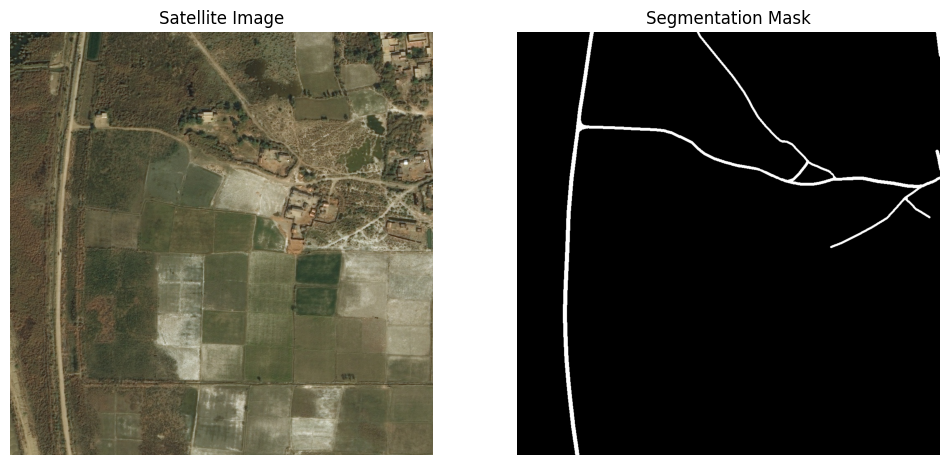

In [2]:
image_path = 'data/608673_sat.jpg'
mask_path = 'data/608673_mask.png'

image_example = cv2.imread(image_path)
mask_example = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv2.cvtColor(image_example, cv2.COLOR_BGR2RGB))
ax[0].set_title('Satellite Image')
ax[0].axis('off')
ax[1].imshow(mask_example, cmap='gray')
ax[1].set_title('Segmentation Mask')
ax[1].axis('off')
plt.show()

In [3]:
# Image and Mask description
print(f"Image shape: {image_example.shape}, Data type: {image_example.dtype}")
print(f"Mask shape: {mask_example.shape}, Data type: {mask_example.dtype}")
print(f"Unique classes in mask: {np.unique(mask_example)}")

Image shape: (1024, 1024, 3), Data type: uint8
Mask shape: (1024, 1024), Data type: uint8
Unique classes in mask: [0 1]


## 2. Defining the Custom Dataset

Here we define the `RoadDataset` class. Since satellite images often come in pairs (Input Image + Mask), this class handles:
1.  **Loading:** Reading the satellite image and its corresponding binary mask (road vs. background).
2.  **Preprocessing:** Converting the mask into a binary tensor (0 for background, 1 for road).

In [9]:
class RoadDataset(Dataset):
    def __init__(self, metadata_file, split, root_dir=".", img_size=(512, 512), sample_fraction=0.5):
        """
        Args:
            metadata_file (str): Path to the csv file.
            split (str): One of 'train', 'val', 'test'.
            root_dir (str): Root directory where 'data/' folder is located.
            img_size (tuple): Target size to resize images (H, W).
            sample_fraction (float): Percentage of data to keep (0.5 = 50%)
        """
        df = pd.read_csv(metadata_file)
        
        # Filter by split
        split_df = df[df['split'] == split]
        self.df = split_df.sample(frac=sample_fraction, random_state=42).reset_index(drop=True)
        self.root_dir = root_dir
        self.img_size = img_size

        # Transformations
        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Construct full file paths
        sat_path = os.path.join(self.root_dir, row['sat_image_path'])
        mask_path = os.path.join(self.root_dir, row['mask_path'])
        
        # Load Image (RGB) and Mask (L = Grayscale/Integer)
        image = Image.open(sat_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        
        # Resize
        if self.img_size:
            image = image.resize(self.img_size, resample=Image.BILINEAR)
            mask = mask.resize(self.img_size, resample=Image.NEAREST)
        
        # To Tensor and Binarize Mask
        image_tensor = self.to_tensor(image)
        mask_tensor = self.to_tensor(mask)
        mask_tensor = (mask_tensor > 0).float()
        if mask_tensor.ndim == 3:
            mask_tensor = mask_tensor.squeeze(0)
            
        return {"image": image_tensor, "mask": mask_tensor}

## 3. The Lightning DataModule

The `DataModule` standardizes the training, validation, and test splits. 
* **Custom Split:** Since the original test set labels are often withheld in challenges, we partition the available training data. We randomly split the dataset into **60% training**, **20% validation**, and **20% testing**.
* **DataLoaders:** This class exposes the `train_dataloader`, `val_dataloader`, and `test_dataloader` that feed batches of images to the model during training.

In [10]:
class RoadDataModule(pl.LightningDataModule):
    def __init__(self, metadata_file, root_dir=".", batch_size=4, num_workers=4):
        super().__init__()
        self.metadata_file = metadata_file
        self.root_dir = root_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        # We use a smaller size (512) to save memory. Set img_size=None to use full 1024.
        self.train_dataset = RoadDataset(self.metadata_file, split='train', 
                                         root_dir=self.root_dir, img_size=(512, 512), sample_fraction=0.5)
        self.val_dataset = RoadDataset(self.metadata_file, split='val', 
                                       root_dir=self.root_dir, img_size=(512, 512), sample_fraction=0.5)
        self.test_dataset = RoadDataset(self.metadata_file, split='test', 
                                        root_dir=self.root_dir, img_size=(512, 512), sample_fraction=0.5)
        
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, 
                          shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, 
                          shuffle=False, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, 
                          shuffle=False, num_workers=self.num_workers)

## 4. Configuring the TorchGeo Task

We utilize TorchGeo's `SemanticSegmentationTask`. This pre-built task class simplifies the workflow by handling:

#### Model Architecture
For this road extraction task, we utilize a **U-Net** architecture with a **MobileNetV2** backbone.

* U-Net Framework: We use the U-Net's "Encoder-Decoder" structure. The *Encoder* extracts features (downsampling), and the *Decoder* reconstructs the segmentation map (upsampling). Most importantly, *Skip Connections* pass detailed spatial information directly from encoder to decoder to preserve sharp road edges. [Link](https://arxiv.org/abs/1505.04597)
* MobileNetV2 Backbone: Instead of a standard encoder, we use a pre-trained MobileNetV2. It uses *Depthwise Separable Convolutions*, making the model significantly lighter and faster to train without sacrificing accuracy. [Link](https://arxiv.org/abs/1801.04381)

#### Loss Function
Since our goal is to classify each pixel into one of two classes—*Road (1)* or *Background (0)*—we use *Binary Cross Entropy (BCE) Loss*.

$$\text{BCE Loss} = - \frac{1}{N} \sum_{i=1}^{N} [y_i \cdot \log(p_i) + (1 - y_i) \cdot \log(1 - p_i)]$$

* How it works: It penalizes the model based on how far the predicted probability ($p$) is from the actual label ($y$).
* Why we use it: It is the standard loss for binary classification tasks. If the pixel is a road ($y=1$), the loss forces the prediction $p$ close to 1. If it's background ($y=0$), it forces $p$ close to 0.

In [ ]:
# Configuration
CSV_FILE = "metadata_split.csv"
BATCH_SIZE = 8      
MAX_EPOCHS = 20
LEARNING_RATE = 1e-4

# Initialize DataModule
datamodule = RoadDataModule(metadata_file=CSV_FILE, batch_size=BATCH_SIZE, num_workers=0)

# Initialize TorchGeo Task
# We use task="binary", loss="bce" (Binary Cross Entropy), and num_classes=1
task = SemanticSegmentationTask(
    model="unet",
    backbone="mobilenet_v2",        # Lightweight backbone
    weights=True,                   # Pretrained encoder weights
    in_channels=3,
    task="binary",                  # Binary Segmentation
    num_classes=1,                  # Single channel output (Probability of Road)
    loss="bce",                     # Binary Cross Entropy
    lr=LEARNING_RATE,
    patience=10
)

## 5. Training the Model

We use the PyTorch Lightning `Trainer` to manage the training process.
* **Callbacks:** We employ callbacks like `ModelCheckpoint` (to save the best model) and `EarlyStopping` (to prevent overfitting).
* **Fit:** The `trainer.fit()` method runs the training loop, iterating over the training data and validating performance after every epoch.

In [12]:
# Callbacks (Model Checkpoint & Early Stopping)
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_loss",
    dirpath="checkpoints",
    filename="road_extraction-{epoch:02d}-{val_loss:.2f}",
    save_top_k=1,
    mode="min"
)

early_stopping = pl.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min"
)

# Trainer
trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=MAX_EPOCHS,
    callbacks=[checkpoint_callback, early_stopping],
    log_every_n_steps=10
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [13]:
print("Starting training...")
trainer.fit(model=task, datamodule=datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting training...



  | Name          | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | model         | Unet              | 6.6 M  | train | 0    
1 | criterion     | BCEWithLogitsLoss | 0      | train | 0    
2 | train_metrics | MetricCollection  | 0      | train | 0    
3 | val_metrics   | MetricCollection  | 0      | train | 0    
4 | test_metrics  | MetricCollection  | 0      | train | 0    
--------------------------------------------------------------------
6.6 M     Trainable params
0         Non-trainable params
6.6 M     Total params
26.516    Total estimated model params size (MB)
294       Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 19: 100%|██████████| 234/234 [31:57<00:00,  0.12it/s, v_num=1]       

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 234/234 [31:57<00:00,  0.12it/s, v_num=1]


In [14]:
print("Starting testing...")
trainer.test(model=task, datamodule=datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting testing...
Testing DataLoader 0: 100%|██████████| 78/78 [00:57<00:00,  1.35it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_BinaryAccuracy      0.9759465456008911
 test_BinaryJaccardIndex    0.5255202651023865
        test_loss           0.06915075331926346
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_BinaryAccuracy': 0.9759465456008911,
  'test_BinaryJaccardIndex': 0.5255202651023865,
  'test_loss': 0.06915075331926346}]

### Understanding the Metrics

#### Binary Accuracy
measures the percentage of pixels that the model classified correctly. The ratio of correct predictions (both "road" and "background") to the total number of pixels in the image.
    $$\text{Accuracy} = \frac{\text{True Positives} + \text{True Negatives}}{\text{Total Pixels}}$$
In satellite imagery, roads often cover only a tiny fraction of the image (e.g., 5%). If the model simply predicts "Background" for *every* pixel, it would still achieve 95% accuracy! Therefore, accuracy can be misleading for imbalanced datasets and should not be the only metric used.

#### Binary Jaccard Index (IoU)
also known as **Intersection over Union (IoU)**, is the standard for segmentation tasks. It measures the overlap between the *predicted* road mask and the *ground truth* road mask. It focuses specifically on the "positive" class (the road).
    $$\text{IoU} = \frac{\text{Intersection}}{\text{Union}} = \frac{|A \cap B|}{|A \cup B|}$$
Unlike accuracy, IoU penalizes the model heavily if it misses the road or hallucinates roads where there are none. A high IoU indicates the model is actually capturing the shape and location of the road network accurately.

#### Loss (Binary Cross Entropy)
is the error value that the model tries to minimize during training. A numerical value representing "how wrong" the model's predictions are. We use **Binary Cross Entropy (BCE)**, which calculates the difference between the predicted probability (0 to 1) and the actual label (0 or 1). We want the Loss to go **down** (towards 0), while we want Accuracy and IoU to go **up** (towards 1).

## 6. Visualization and Inference

Finally, we visualize the model's performance on the test set.
* **Satellite Image:** The raw input.
* **Ground Truth:** The actual labeled road network.
* **Prediction:** The road network predicted by our model.

Comparing the Prediction to the Ground Truth allows us to qualitatively assess how well the model handles different terrains and occlusions.

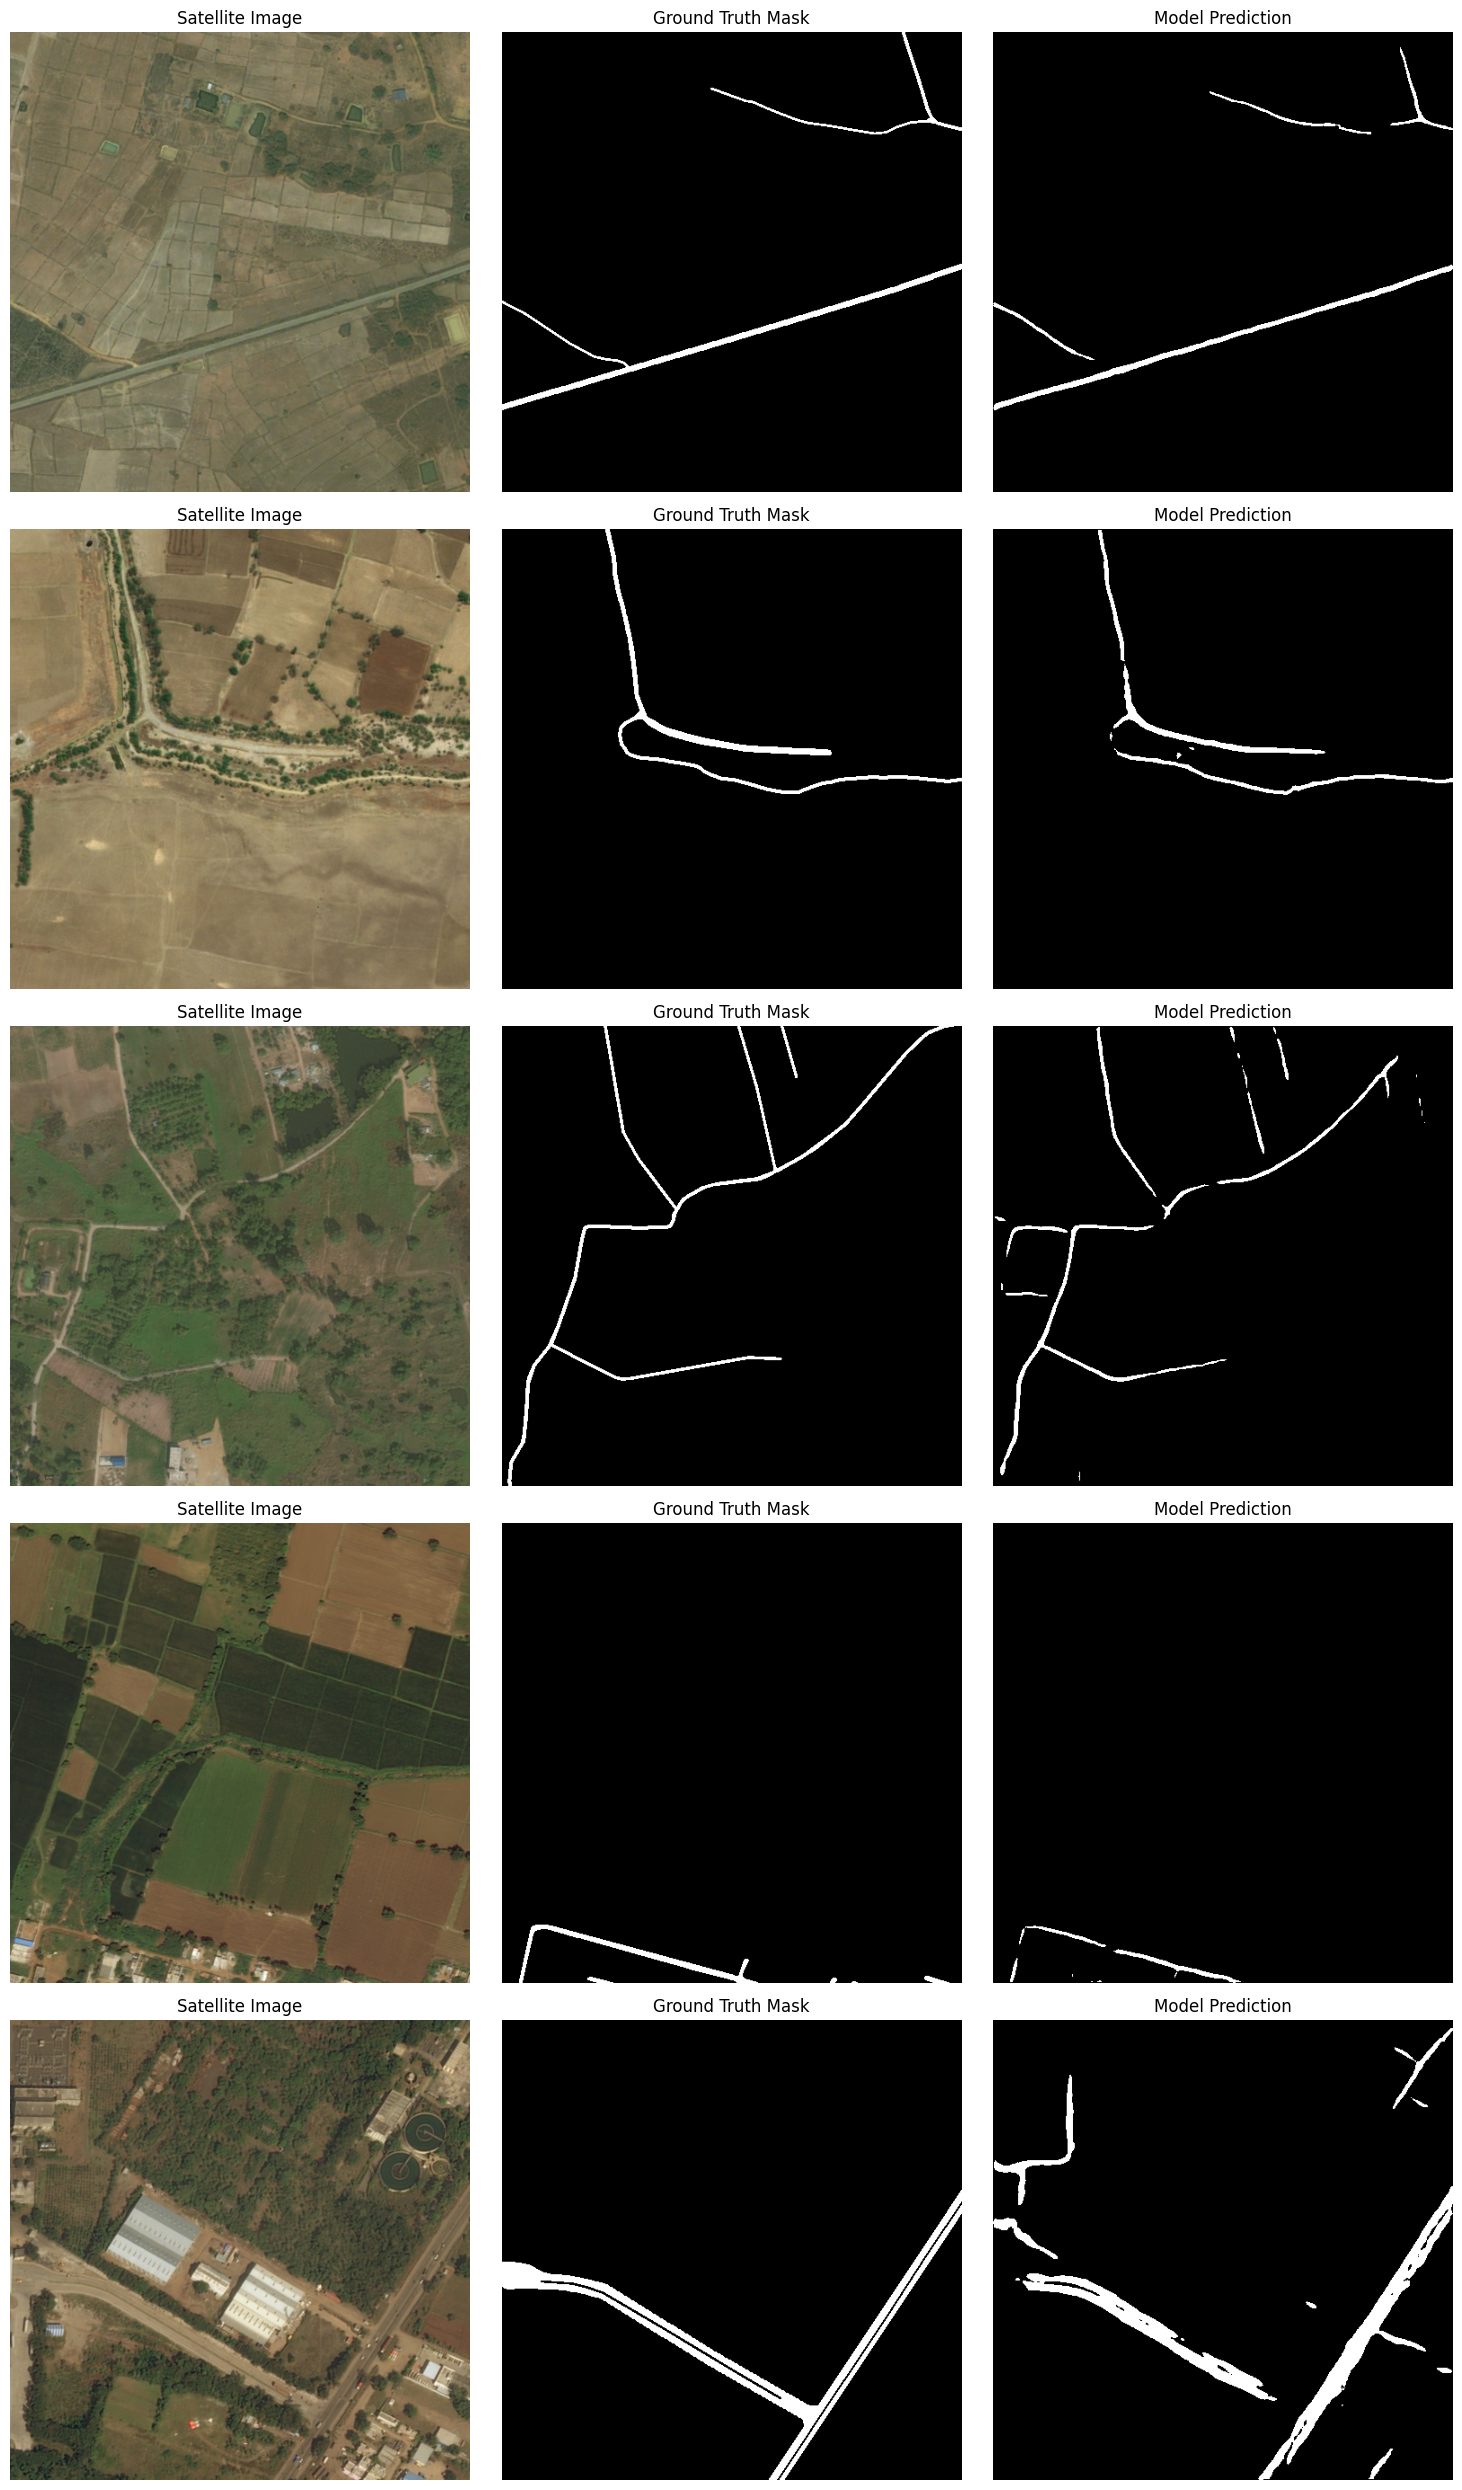

In [15]:
def visualize_results(model, datamodule, num_samples=5):
    # 1. Setup
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval() # Set to evaluation mode
    
    # 2. Get a batch of data
    # We create an iterator to grab just one batch
    dataloader = datamodule.test_dataloader()
    batch = next(iter(dataloader))
    
    # 3. Prepare inputs
    images = batch["image"].to(device)
    masks = batch["mask"].to(device)
    
    # 4. Run Inference
    with torch.no_grad():
        # Pass only the image tensor to the model
        logits = model(images)
        
        # Apply Sigmoid to turn Logits -> Probabilities (0.0 to 1.0)
        probs = torch.sigmoid(logits)
        
        # Threshold to get Binary Mask (0 or 1)
        preds = (probs > 0.5).float()

    # 5. Plotting
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    # Handle case where batch size < num_samples
    actual_samples = min(num_samples, images.shape[0])
    
    for i in range(actual_samples):
        # --- Input Image ---
        # PyTorch is (C, H, W), Matplotlib needs (H, W, C)
        img_np = images[i].cpu().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("Satellite Image")
        axes[i, 0].axis("off")
        
        # --- Ground Truth ---
        # Squeeze removes the channel dim: (1, H, W) -> (H, W)
        mask_np = masks[i].cpu().squeeze().numpy()
        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")
        
        # --- Prediction ---
        pred_np = preds[i].cpu().squeeze().numpy()
        axes[i, 2].imshow(pred_np, cmap="gray")
        axes[i, 2].set_title("Model Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_results(task, datamodule, num_samples=5)

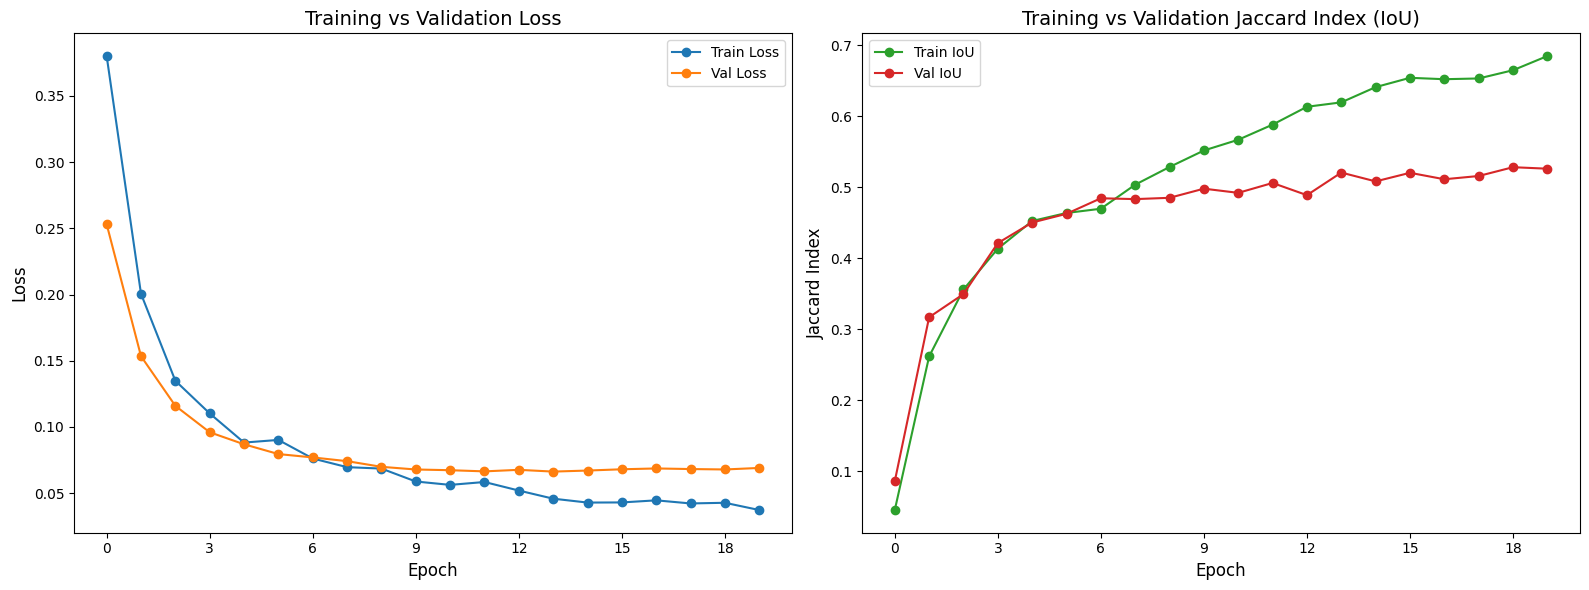

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

metrics_df = pd.read_csv('lightning_logs/version_1/metrics.csv')
epoch_metrics = metrics_df.groupby('epoch').mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Loss ---
axes[0].plot(epoch_metrics.index, epoch_metrics['train_loss'], 
             label='Train Loss', color='tab:blue', marker='o', linestyle='-')
axes[0].plot(epoch_metrics.index, epoch_metrics['val_loss'], 
             label='Val Loss', color='tab:orange', marker='o', linestyle='-')
axes[0].set_title('Training vs Validation Loss', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# --- Plot 2: Jaccard Index (IoU) ---
axes[1].plot(epoch_metrics.index, epoch_metrics['train_BinaryJaccardIndex'], 
             label='Train IoU', color='tab:green', marker='o', linestyle='-')
axes[1].plot(epoch_metrics.index, epoch_metrics['val_BinaryJaccardIndex'], 
             label='Val IoU', color='tab:red', marker='o', linestyle='-')
axes[1].set_title('Training vs Validation Jaccard Index (IoU)', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Jaccard Index', fontsize=12)
axes[1].legend()
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()